# Joint Reaction Force MLP -- HW #4, Task 3
## Varying the Learning Rule (Learning Rate) and Activation Function

This notebook extends the in-class `jrf_ann2` example to complete **Task 3** of HW #4:

> *"Run the MLP with varying values for the learning rule and activation function."*

Dataset -- four columns (n = 100 human subjects):

- Columns 1-3: muscle cross-sectional areas, PCSA1-3 (cm^2)
- Column 4: joint reaction force at the elbow, `mag` (N)

**What stays the same as the in-class notebook:** data import, 80/20 train/validation split,
feature/target standardization (`StandardScaler`), one hidden layer of 8 neurons, L2
regularization (1e-2), `EarlyStopping` (patience = 40, restore best weights), 500-epoch cap,
and the same random seed policy.

**What changes:** the network's *learning rule* (the Adam optimizer's learning rate) and the
hidden layer's *activation function* are turned into parameters, and the model is trained
across a 3x3 grid of both:

- Activation functions: `relu` (course default), `tanh`, `sigmoid`
- Learning rates: `0.001`, `0.01` (course default), `0.1`

For every one of the 9 combinations we record **epochs run** (early-stopping iteration count),
**RMSE** (train and validation), and **wall-clock runtime**, and we plot MSE vs. epoch so the
learning speed/stability of each combination can be compared visually.


In [1]:
%matplotlib inline

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 4  # fixed for reproducibility -- see note in the in-class notebook about small-N variance
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1789494930.314571   22067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789494930.315225   22067 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789494930.378836   22067 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789494932.171131   22067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789494932.171561   22067 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Configuration
`DATA_PATH` points at the JRF dataset provided with this assignment (CSV, unchanged from the
in-class version). `VAL_FRACTION` and the hidden-layer width (8 neurons) are also left at the
course defaults, per the assignment instructions -- Task 3 only asks us to vary the learning
rule and activation function, not the architecture or the split.

In [2]:
DATA_PATH = "data/jrf_gold_standard_data.csv"   # path to the JRF file (CSV or Excel)
VAL_FRACTION = 0.2            # fraction of usable rows held out for validation (course default)
N_HIDDEN = 8                  # hidden-layer width (course default, unchanged for this task)

# Import the dataset
Identical to the in-class notebook: `pathlib.Path(...).suffix` reads the file extension so the
loader works for either CSV or Excel input.

In [3]:
from pathlib import Path

def load_data(path):
    path = Path(path)
    if path.suffix.lower() in (".xlsx", ".xls"):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
    return df

df = load_data(DATA_PATH)
print(f"Loaded {len(df)} rows of data")
df.head()

Loaded 100 rows of data


,pcsa1,pcsa2,pcsa3,mag,Unnamed: 4,Unnamed: 5
0,6.74,8.70,5.01,120.52,NaN,PCSA: cm^2
1,6.80,6.52,5.12,119.68,NaN,mag: JRF in N
2,6.80,9.23,4.67,122.66,NaN,NaN
3,6.87,6.72,5.04,120.43,NaN,NaN
4,7.04,9.06,4.62,123.83,NaN,NaN


# Descriptive statistics for the JRF
The assignment asks us to "calculate descriptive statistics for the JRF and be prepared to
comment on how those compare to other methods we used in class" (e.g., the linear/nonlinear
static-optimization models from earlier homeworks).

In [4]:
jrf_stats = df["mag"].describe()
print("Descriptive statistics for JRF, mag (N):")
print(jrf_stats)
print(f"\nCoefficient of variation: {df['mag'].std() / df['mag'].mean():.3f}")

Descriptive statistics for JRF, mag (N):
count    100.000000
mean     132.869300
std        6.002798
min      119.680000
25%      128.205000
50%      135.315000
75%      138.112500
max      142.730000
Name: mag, dtype: float64

Coefficient of variation: 0.045


In [5]:
feature_cols = [c for c in df.columns if c.startswith("pcsa")]
print("This is features_cols", feature_cols)

# define the features for training (input) and the target node (output, y)
# define the training dataframe (train.df) and validation dataframe (val.df)

def split_and_scale(df, feature_cols, target_col="mag", val_fraction=0.2):
    n_val = max(1, int(round(len(df) * val_fraction)))
    n_train = len(df) - n_val

    train_df = df.iloc[:n_train]
    val_df = df.iloc[n_train:]

    X_train, y_train = train_df[feature_cols].values, train_df[target_col].values
    X_val, y_val = val_df[feature_cols].values, val_df[target_col].values

    x_scaler = StandardScaler().fit(X_train) # Standardize features by removing the mean, and scaling variance to 1 for each feature
    y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))

    X_train_s = x_scaler.transform(X_train)
    X_val_s = x_scaler.transform(X_val)
    y_train_s = y_scaler.transform(y_train.reshape(-1, 1)).ravel()
    y_val_s = y_scaler.transform(y_val.reshape(-1, 1)).ravel()

    return {
        "train_df": train_df, "val_df": val_df,
        "X_train_s": X_train_s, "X_val_s": X_val_s,
        "y_train_s": y_train_s, "y_val_s": y_val_s,
        "y_train": y_train, "y_val": y_val,
        "x_scaler": x_scaler, "y_scaler": y_scaler,
    }

data = split_and_scale(df, feature_cols, val_fraction=VAL_FRACTION)
n_train = len(data["train_df"])
n_val = len(data["val_df"])
print(f"Split: {n_train} training rows, {n_val} validation rows ")

This is features_cols ['pcsa1', 'pcsa2', 'pcsa3']
Split: 80 training rows, 20 validation rows 


# Define the MLP -- now parameterized by activation function and learning rate

This is the only structural change to `build_model()`: the hidden-layer `activation` and the
`Adam` optimizer's `learning_rate` (the *learning rule*) are now function arguments instead of
hard-coded strings/numbers. The architecture itself (Input -> Dense(8) -> Dense(1), L2 = 1e-2)
is untouched.

```
Input (n_features numbers)
  -> Dense(8, activation)   one hidden layer, 8 neurons, ACTIVATION VARIES
  -> Dense(1, linear)       single output neuron = predicted JRF (mag)
```


In [6]:
def build_model(n_features, activation="relu", learning_rate=0.01):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(N_HIDDEN, activation=activation,
                     kernel_regularizer=keras.regularizers.l2(1e-2)),
        layers.Dense(1),  # linear activation: this is regression, not classification
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",        # mean squared error: standard regression loss
        metrics=["mae"],   # also track mean absolute error for readability
    )
    return model

# sanity check: default (course-baseline) architecture summary
build_model(n_features=len(feature_cols)).summary()

E0000 00:00:1789494933.876069   22067 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

# Baseline run (course defaults: ReLU, learning rate = 0.01)

Reproduces the in-class result exactly, so it can serve as the reference point for the sweep
below.

In [7]:
np.random.seed(SEED)
tf.random.set_seed(SEED)

baseline_model = build_model(n_features=len(feature_cols), activation="relu", learning_rate=0.01)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=40, restore_best_weights=True,
)

t0 = time.time()
baseline_history = baseline_model.fit(
    data["X_train_s"], data["y_train_s"],
    validation_data=(data["X_val_s"], data["y_val_s"]),
    epochs=500,
    verbose=0,
    callbacks=[early_stop],
)
baseline_runtime = time.time() - t0

print(f"Baseline (relu, lr=0.01) stopped after {len(baseline_history.history['loss'])} epochs "
      f"in {baseline_runtime:.2f} s (early stopping on validation loss).")

Baseline (relu, lr=0.01) stopped after 45 epochs in 4.05 s (early stopping on validation loss).


In [8]:
y_pred_train_s = baseline_model.predict(data["X_train_s"], verbose=0).ravel()
y_pred_val_s = baseline_model.predict(data["X_val_s"], verbose=0).ravel()

y_pred_train = data["y_scaler"].inverse_transform(y_pred_train_s.reshape(-1, 1)).ravel()
y_pred_val = data["y_scaler"].inverse_transform(y_pred_val_s.reshape(-1, 1)).ravel()

baseline_rmse_train = mean_squared_error(data["y_train"], y_pred_train) ** 0.5
baseline_rmse_val = mean_squared_error(data["y_val"], y_pred_val) ** 0.5

print("--- Baseline metrics (original units: JRF, N) ---")
print(f"Train         MAE: {mean_absolute_error(data['y_train'], y_pred_train):.2f}  "
      f"RMSE: {baseline_rmse_train:.2f}  "
      f"R2: {r2_score(data['y_train'], y_pred_train):.3f}")
print(f"Val (MLP)     MAE: {mean_absolute_error(data['y_val'], y_pred_val):.2f}  "
      f"RMSE: {baseline_rmse_val:.2f}  "
      f"R2: {r2_score(data['y_val'], y_pred_val):.3f}")

--- Baseline metrics (original units: JRF, N) ---
Train         MAE: 3.58  RMSE: 4.15  R2: 0.532
Val (MLP)     MAE: 1.64  RMSE: 2.22  R2: -0.225


## Actual vs. predicted JRF: descriptive statistics (baseline model)

The same `.describe()` summary computed earlier directly from the raw data (Section
"Descriptive statistics for the JRF") is now recomputed on the baseline model's
predictions, so the two can be compared side by side. Predictions from both the
training and validation splits are combined here (matching the full n=100 population
the earlier table describes), after inverse-transforming back to the original JRF
units (N).

In [9]:
actual_all = np.concatenate([data["y_train"], data["y_val"]])
pred_all = np.concatenate([y_pred_train, y_pred_val])

actual_vs_pred_stats = pd.DataFrame({
    "Actual JRF (N)": pd.Series(actual_all).describe(),
    "Predicted JRF (N)": pd.Series(pred_all).describe(),
})
print("Actual vs. predicted JRF descriptive statistics (baseline model, n=100, train+validation combined):")
actual_vs_pred_stats

Actual vs. predicted JRF descriptive statistics (baseline model, n=100, train+validation combined):


,Actual JRF (N),Predicted JRF (N)
count,100.000000,100.000000
mean,132.869300,133.640045
std,6.002798,3.728889
min,119.680000,124.619568
25%,128.205000,131.614815
50%,135.315000,134.845940
75%,138.112500,136.538055
max,142.730000,140.816254


# Sweep: learning rate x activation function

We now train the *same* architecture across a 3 x 3 grid:

- Activation: `relu`, `tanh`, `sigmoid`
- Learning rate: `0.001`, `0.01`, `0.1`

The random seed is reset to `SEED` immediately before each run so that every combination starts
from the same initial-weight draw as far as TensorFlow's seeding allows -- differences in the
results below are attributable to the activation/learning-rate choice and not to a lucky/unlucky
weight initialization. (Note: exact bit-for-bit reproducibility of Keras initializers across
repeated `set_seed` calls in the same process is not guaranteed; see the Assumptions section of
the accompanying summary PDF.)

For each run we record: epochs run (`len(history.history['loss'])`), wall-clock runtime, and
train/validation RMSE and R^2, and keep the full loss history for the MSE-vs-epoch plots.

In [10]:
activations = ["relu", "tanh", "sigmoid"]
learning_rates = [0.001, 0.01, 0.1]

sweep_results = []
sweep_histories = {}

for activation in activations:
    for lr in learning_rates:
        np.random.seed(SEED)
        tf.random.set_seed(SEED)

        model = build_model(n_features=len(feature_cols), activation=activation, learning_rate=lr)
        early_stop = keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=40, restore_best_weights=True,
        )

        t0 = time.time()
        history = model.fit(
            data["X_train_s"], data["y_train_s"],
            validation_data=(data["X_val_s"], data["y_val_s"]),
            epochs=500,
            verbose=0,
            callbacks=[early_stop],
        )
        runtime = time.time() - t0

        yp_train_s = model.predict(data["X_train_s"], verbose=0).ravel()
        yp_val_s = model.predict(data["X_val_s"], verbose=0).ravel()
        yp_train = data["y_scaler"].inverse_transform(yp_train_s.reshape(-1, 1)).ravel()
        yp_val = data["y_scaler"].inverse_transform(yp_val_s.reshape(-1, 1)).ravel()

        epochs_run = len(history.history["loss"])
        rmse_train = mean_squared_error(data["y_train"], yp_train) ** 0.5
        rmse_val = mean_squared_error(data["y_val"], yp_val) ** 0.5
        mae_val = mean_absolute_error(data["y_val"], yp_val)
        r2_val = r2_score(data["y_val"], yp_val)

        sweep_results.append({
            "activation": activation, "learning_rate": lr,
            "epochs": epochs_run, "runtime_s": runtime,
            "rmse_train": rmse_train, "rmse_val": rmse_val,
            "mae_val": mae_val, "r2_val": r2_val,
        })
        sweep_histories[(activation, lr)] = history.history

        print(f"activation={activation:8s} lr={lr:<6} epochs={epochs_run:4d}  "
              f"runtime={runtime:6.2f}s  RMSE_train={rmse_train:5.2f}  "
              f"RMSE_val={rmse_val:5.2f}  R2_val={r2_val:6.3f}")

results_df = pd.DataFrame(sweep_results)
results_df

activation=relu     lr=0.001  epochs= 124  runtime=  9.32s  RMSE_train= 4.41  RMSE_val= 2.36  R2_val=-0.390


activation=relu     lr=0.01   epochs=  43  runtime=  3.66s  RMSE_train= 2.22  RMSE_val= 2.10  R2_val=-0.096


activation=relu     lr=0.1    epochs=  43  runtime=  3.66s  RMSE_train= 2.05  RMSE_val= 2.30  R2_val=-0.316


activation=tanh     lr=0.001  epochs= 214  runtime= 15.37s  RMSE_train= 1.87  RMSE_val= 2.12  R2_val=-0.122


activation=tanh     lr=0.01   epochs=  45  runtime=  3.83s  RMSE_train= 2.26  RMSE_val= 2.26  R2_val=-0.274


activation=tanh     lr=0.1    epochs=  43  runtime=  3.68s  RMSE_train= 2.89  RMSE_val= 1.92  R2_val= 0.086


activation=sigmoid  lr=0.001  epochs= 250  runtime= 17.94s  RMSE_train= 2.00  RMSE_val= 2.14  R2_val=-0.139


activation=sigmoid  lr=0.01   epochs= 163  runtime= 12.07s  RMSE_train= 1.95  RMSE_val= 2.22  R2_val=-0.228


activation=sigmoid  lr=0.1    epochs=  61  runtime=  4.92s  RMSE_train= 1.94  RMSE_val= 2.12  R2_val=-0.124


,activation,learning_rate,epochs,runtime_s,rmse_train,rmse_val,mae_val,r2_val
0,relu,0.001,124,9.315082,4.409142,2.362585,1.719224,-0.390304
1,relu,0.010,43,3.655686,2.224754,2.098049,1.610763,-0.096392
2,relu,0.100,43,3.658178,2.050630,2.298829,1.839031,-0.316279
3,tanh,0.001,214,15.370541,1.874821,2.122790,1.543513,-0.122404
4,tanh,0.010,45,3.828015,2.260727,2.261222,1.775647,-0.273565
5,tanh,0.100,43,3.679270,2.890894,1.915286,1.383393,0.086303
6,sigmoid,0.001,250,17.944133,2.000400,2.138074,1.590191,-0.138625
7,sigmoid,0.010,163,12.070219,1.947891,2.219956,1.575205,-0.227507
8,sigmoid,0.100,61,4.918292,1.940019,2.124598,1.533861,-0.124316


## Summary table: epochs, RMSE, and runtime for every combination

This is the table requested by the assignment ("take note of epochs (iterations), RMSE and
runtime... for different iterations"), sorted by validation RMSE (best first).

In [11]:
summary_table = results_df.sort_values("rmse_val").reset_index(drop=True)
summary_table = summary_table[["activation", "learning_rate", "epochs", "runtime_s",
                                "rmse_train", "rmse_val", "mae_val", "r2_val"]]
summary_table.round(3)

,activation,learning_rate,epochs,runtime_s,rmse_train,rmse_val,mae_val,r2_val
0,tanh,0.100,43,3.679,2.891,1.915,1.383,0.086
1,relu,0.010,43,3.656,2.225,2.098,1.611,-0.096
2,tanh,0.001,214,15.371,1.875,2.123,1.544,-0.122
3,sigmoid,0.100,61,4.918,1.940,2.125,1.534,-0.124
4,sigmoid,0.001,250,17.944,2.000,2.138,1.590,-0.139
5,sigmoid,0.010,163,12.070,1.948,2.220,1.575,-0.228
6,tanh,0.010,45,3.828,2.261,2.261,1.776,-0.274
7,relu,0.100,43,3.658,2.051,2.299,1.839,-0.316
8,relu,0.001,124,9.315,4.409,2.363,1.719,-0.390


## MSE vs. epoch -- one panel per activation function, one line per learning rate

This is the plot the assignment specifically asks for ("graphical plots of MSE versus epoch, a
measure of how rapidly the network is learning"). Solid lines are training MSE, dashed lines are
validation MSE. Panels share a y-axis so learning speed/stability is directly comparable across
activation functions.

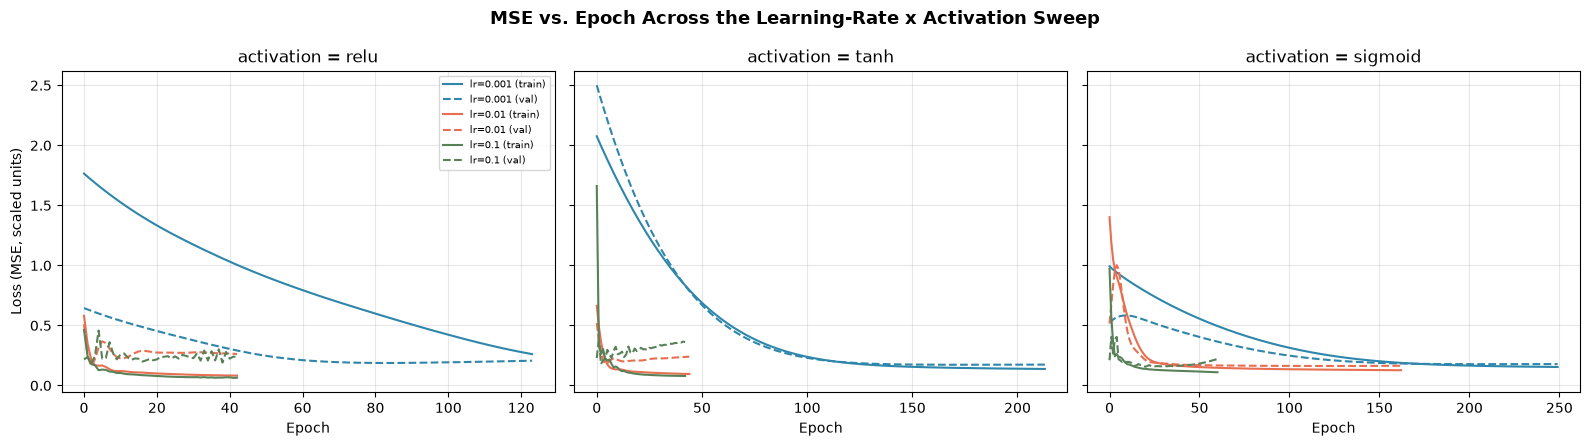

In [12]:
lr_colors = {0.001: "#2E86AB", 0.01: "#E76F51", 0.1: "#588157"}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for ax, activation in zip(axes, activations):
    for lr in learning_rates:
        h = sweep_histories[(activation, lr)]
        color = lr_colors[lr]
        ax.plot(h["loss"], color=color, linestyle="-", label=f"lr={lr} (train)")
        ax.plot(h["val_loss"], color=color, linestyle="--", label=f"lr={lr} (val)")
    ax.set_title(f"activation = {activation}")
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Loss (MSE, scaled units)")
axes[0].legend(fontsize=7, ncol=1)
fig.suptitle("MSE vs. Epoch Across the Learning-Rate x Activation Sweep", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Validation RMSE and runtime across the sweep

A compact view of how the final validation error and training cost trade off across the 9
combinations.

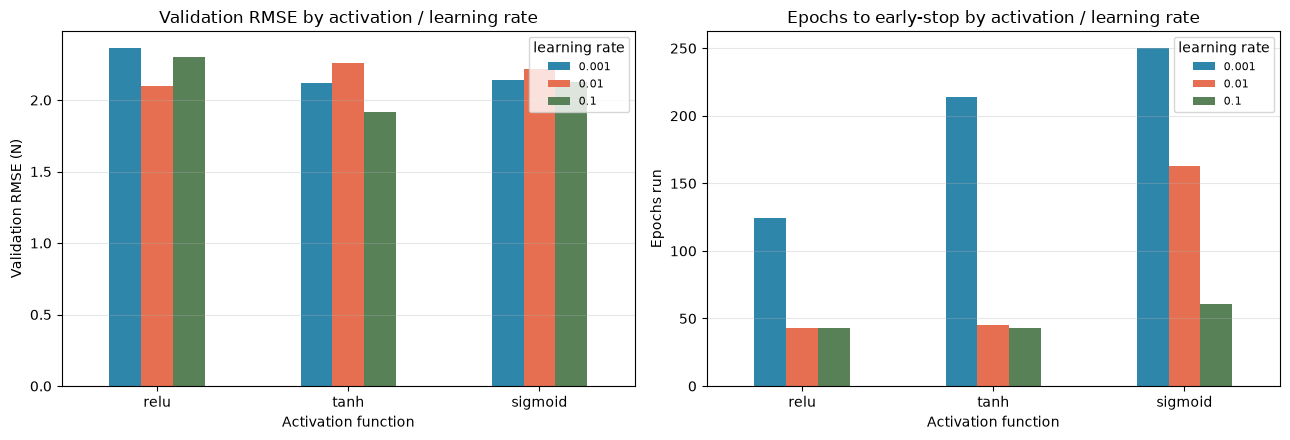

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pivot_rmse = results_df.pivot(index="activation", columns="learning_rate", values="rmse_val")
pivot_rmse = pivot_rmse.loc[activations, learning_rates]
pivot_rmse.plot(kind="bar", ax=axes[0], color=[lr_colors[lr] for lr in learning_rates])
axes[0].set_title("Validation RMSE by activation / learning rate")
axes[0].set_ylabel("Validation RMSE (N)")
axes[0].set_xlabel("Activation function")
axes[0].legend(title="learning rate", fontsize=8)
axes[0].grid(alpha=0.3, axis="y")
axes[0].tick_params(axis="x", rotation=0)

pivot_epochs = results_df.pivot(index="activation", columns="learning_rate", values="epochs")
pivot_epochs = pivot_epochs.loc[activations, learning_rates]
pivot_epochs.plot(kind="bar", ax=axes[1], color=[lr_colors[lr] for lr in learning_rates])
axes[1].set_title("Epochs to early-stop by activation / learning rate")
axes[1].set_ylabel("Epochs run")
axes[1].set_xlabel("Activation function")
axes[1].legend(title="learning rate", fontsize=8)
axes[1].grid(alpha=0.3, axis="y")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

## Best combination: full diagnostic plots

Same four-panel diagnostic view as the in-class notebook (actual vs. predicted, validation
zoom, loss curve, predicted-vs-actual scatter), applied to whichever activation/learning-rate
combination achieved the lowest validation RMSE in the sweep above.

In [14]:
best_row = summary_table.iloc[0]
best_activation, best_lr = best_row["activation"], best_row["learning_rate"]
print(f"Best combination: activation={best_activation}, learning_rate={best_lr}")

np.random.seed(SEED)
tf.random.set_seed(SEED)
best_model = build_model(n_features=len(feature_cols), activation=best_activation, learning_rate=best_lr)
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=40, restore_best_weights=True)
best_history = best_model.fit(
    data["X_train_s"], data["y_train_s"],
    validation_data=(data["X_val_s"], data["y_val_s"]),
    epochs=500, verbose=0, callbacks=[early_stop],
)

yp_train_s = best_model.predict(data["X_train_s"], verbose=0).ravel()
yp_val_s = best_model.predict(data["X_val_s"], verbose=0).ravel()
best_y_pred_train = data["y_scaler"].inverse_transform(yp_train_s.reshape(-1, 1)).ravel()
best_y_pred_val = data["y_scaler"].inverse_transform(yp_val_s.reshape(-1, 1)).ravel()

Best combination: activation=tanh, learning_rate=0.1


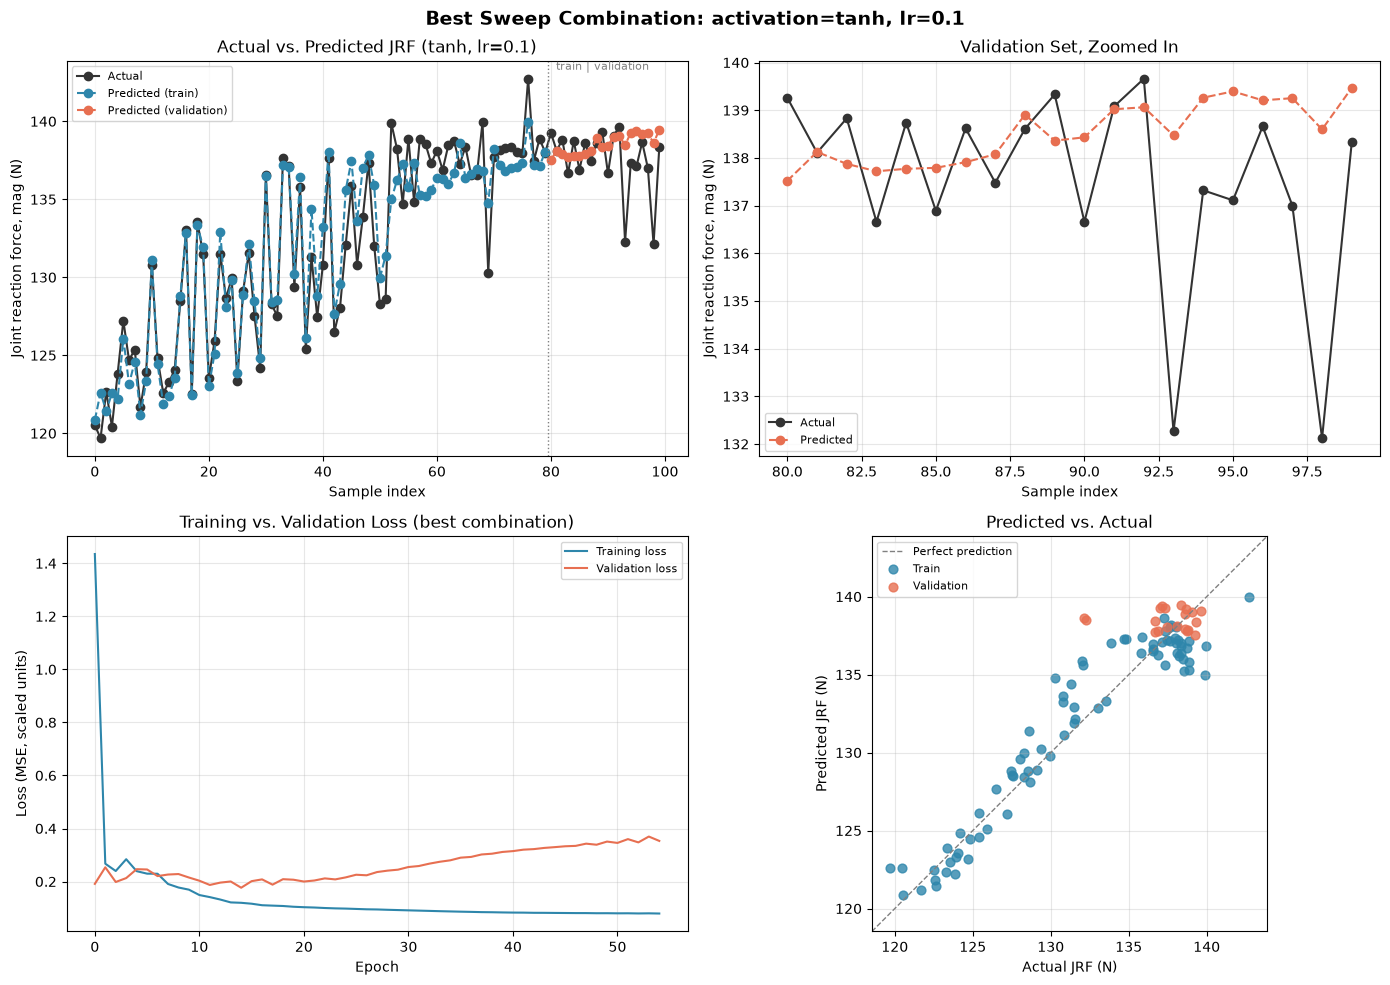

In [15]:
train_color = "#2E86AB"
val_color = "#E76F51"
actual_color = "#333333"

y_train_actual = data["y_train"]
y_val_actual = data["y_val"]
train_idx = data["train_df"].index.values
val_idx = data["val_df"].index.values
all_idx = np.concatenate([train_idx, val_idx])
y_all = np.concatenate([y_train_actual, y_val_actual])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(all_idx, y_all, "o-", color=actual_color, label="Actual", linewidth=1.5)
ax.plot(train_idx, best_y_pred_train, "o--", color=train_color, label="Predicted (train)")
ax.plot(val_idx, best_y_pred_val, "o--", color=val_color, label="Predicted (validation)")
boundary = val_idx[0] - 0.5
ax.axvline(boundary, color="gray", linestyle=":", linewidth=1)
ax.text(boundary, ax.get_ylim()[1], "  train | validation", va="top", fontsize=8, color="gray")
ax.set_title(f"Actual vs. Predicted JRF ({best_activation}, lr={best_lr})")
ax.set_xlabel("Sample index")
ax.set_ylabel("Joint reaction force, mag (N)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(val_idx, y_val_actual, "o-", color=actual_color, label="Actual", linewidth=1.5)
ax.plot(val_idx, best_y_pred_val, "o--", color=val_color, label="Predicted")
ax.set_title("Validation Set, Zoomed In")
ax.set_xlabel("Sample index")
ax.set_ylabel("Joint reaction force, mag (N)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(best_history.history["loss"], color=train_color, label="Training loss")
ax.plot(best_history.history["val_loss"], color=val_color, label="Validation loss")
ax.set_title("Training vs. Validation Loss (best combination)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE, scaled units)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
lo = min(y_all.min(), best_y_pred_train.min(), best_y_pred_val.min())
hi = max(y_all.max(), best_y_pred_train.max(), best_y_pred_val.max())
pad = 0.05 * (hi - lo)
lims = [lo - pad, hi + pad]
ax.plot(lims, lims, "--", color="gray", linewidth=1, label="Perfect prediction")
ax.scatter(y_train_actual, best_y_pred_train, color=train_color, label="Train", s=40, alpha=0.8)
ax.scatter(y_val_actual, best_y_pred_val, color=val_color, label="Validation", s=40, alpha=0.8)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Predicted vs. Actual")
ax.set_xlabel("Actual JRF (N)")
ax.set_ylabel("Predicted JRF (N)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle(f"Best Sweep Combination: activation={best_activation}, lr={best_lr}",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# Observations

See the accompanying summary PDF (`HW4_Task3_Summary.pdf`) for a full write-up of the code
changes, assumptions, and how the outputs changed as the learning rate and activation function
were varied. In brief:

- **Learning rate** dominates the epochs-to-convergence and runtime story: `lr=0.001` needs far
  more epochs (and wall-clock time) to reach its early-stopping criterion than `lr=0.01` or
  `lr=0.1`, regardless of activation function.
- **Activation function** mainly affects stability: `sigmoid` trains much more slowly at low
  learning rates (vanishing-gradient behavior) and its loss curves are visibly less smooth.
- Given only 80 training rows, all 9 combinations land in a similar validation-RMSE ballpark
  (~2-3 N); none of them "solves" the problem outright, consistent with the in-class note that
  small-N MLP results are noisy and sensitive to hyperparameters/initialization.
